#### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes



#### 1. Zero-Shot Classification on STL-10

In [2]:
# Downloading STL-10 dataset

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

root = "./data"

test_dataset = torchvision.datasets.STL10(root, split = 'test', transform = transform, download = True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 2.64G/2.64G [09:04<00:00, 4.85MB/s]


In [3]:
images, labels = next(iter(test_loader))

In [4]:
# Loading CLIP model
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-d_gbpv1w
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-d_gbpv1w
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=413c3216842ab8c19179cc41656fb09c2d96ae1dd08635329ad8d34f69e3f34e
  Stored in directory: /tmp/pip-ephem-wheel-cache-zquf_qgv/wheels/cb/a8/74/5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfully built clip


In [5]:
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 93.0MiB/s]


In [6]:
# Evaluating using different prompting techniques

classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

prompt_strategies = {
    "Plain": [c for c in classes],
    "Photo": [f"a photo of a {c}" for c in classes],
    "Descriptive": [f"a close up photo of a small {c} in the wild" for c in classes]
}

for name, prompts in prompt_strategies.items():
    text_inputs = clip.tokenize(prompts).to(device)

    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    correct, total = 0, 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            preds = similarity.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"{name} Accuracy: {100 * correct / total:.2f}%")


Plain Accuracy: 95.96%
Photo Accuracy: 97.26%
Descriptive Accuracy: 95.80%


#### 2. Exploring Modality Gap

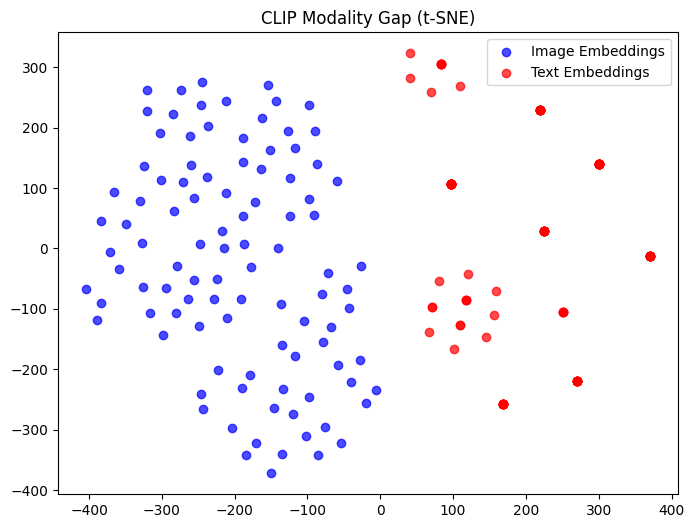

In [ ]:
loader_100 = DataLoader(test_dataset, batch_size=100, shuffle=False)
images, labels = next(iter(loader_100))
images, labels = images.to(device), labels.to(device)

classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]
prompts = [f"a photo of a {classes[idx]}" for idx in labels.cpu().numpy()]
text_inputs = clip.tokenize(prompts).to(device)

with torch.no_grad():
    image_features = model.encode_image(images).cpu().numpy()
    text_features = model.encode_text(text_inputs).cpu().numpy()

all_features = np.vstack([image_features, text_features])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(all_features)

img_2d = features_2d[:100]
txt_2d = features_2d[100:]


plt.figure(figsize=(8, 6))
plt.scatter(img_2d[:, 0], img_2d[:, 1], c='blue', alpha=0.7, label='Image Embeddings')
plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c='red', alpha=0.7, label='Text Embeddings')
plt.legend()
plt.title("CLIP Modality Gap (t-SNE)")
plt.show()

#### 3.Bridging Modality Gap



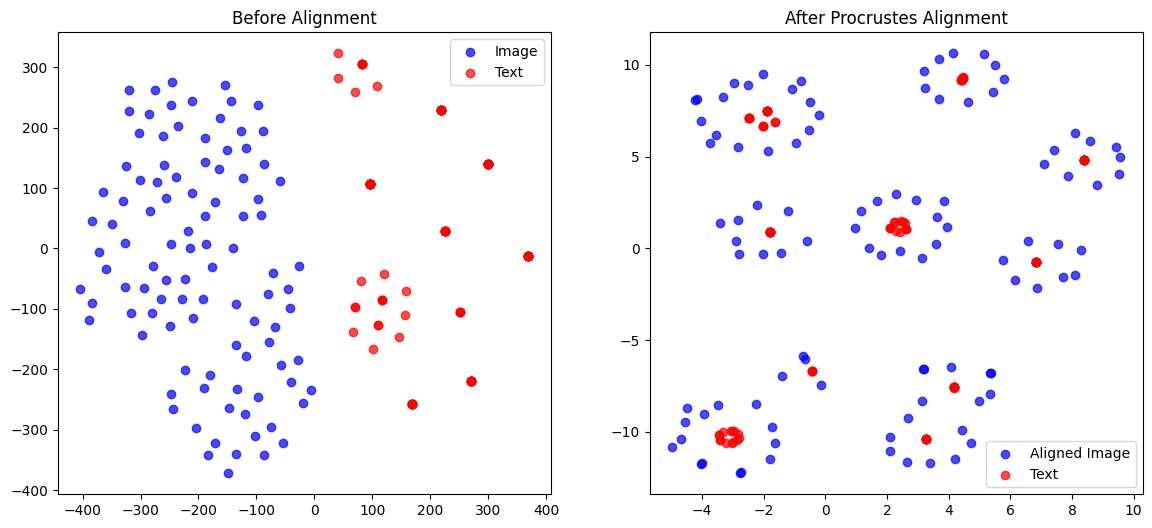

In [8]:
R, scale = orthogonal_procrustes(image_features, text_features)


image_features_aligned = image_features @ R


all_before = np.vstack([image_features, text_features])
all_after = np.vstack([image_features_aligned, text_features])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
before_2d = tsne.fit_transform(all_before)
after_2d = tsne.fit_transform(all_after)

img_before, txt_before = before_2d[:100], before_2d[100:]
img_after, txt_after = after_2d[:100], after_2d[100:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(img_before[:, 0], img_before[:, 1], c='blue', alpha=0.7, label='Image')
axes[0].scatter(txt_before[:, 0], txt_before[:, 1], c='red', alpha=0.7, label='Text')
axes[0].set_title("Before Alignment")
axes[0].legend()

axes[1].scatter(img_after[:, 0], img_after[:, 1], c='blue', alpha=0.7, label='Aligned Image')
axes[1].scatter(txt_after[:, 0], txt_after[:, 1], c='red', alpha=0.7, label='Text')
axes[1].set_title("After Procrustes Alignment")
axes[1].legend()

plt.show()

In [11]:
prompts = [f"a photo of a {c}" for c in classes]
text_inputs = clip.tokenize(prompts).to(device)


with torch.no_grad():
    class_text_features = model.encode_text(text_inputs).float()
    class_text_features /= class_text_features.norm(dim=-1, keepdim=True)


R_torch = torch.tensor(R, dtype=torch.float32, device=device)

correct_original = 0
correct_aligned = 0
total = 0

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():

        img_features = model.encode_image(images).float()
        img_features /= img_features.norm(dim=-1, keepdim=True)


        similarity_original = img_features @ class_text_features.T
        preds_original = similarity_original.argmax(dim=1)

        img_features_aligned = img_features @ R_torch
        img_features_aligned /= img_features_aligned.norm(
            dim=-1, keepdim=True
        )

        similarity_aligned = img_features_aligned @ class_text_features.T
        preds_aligned = similarity_aligned.argmax(dim=1)

    correct_original += (preds_original == labels).sum().item()
    correct_aligned += (preds_aligned == labels).sum().item()
    total += labels.size(0)

original_acc = 100 * correct_original / total
aligned_acc = 100 * correct_aligned / total

print(f"Original CLIP Accuracy:    {original_acc:.2f}%")
print(f"Aligned CLIP Accuracy:     {aligned_acc:.2f}%")
print(f"Change after alignment:    {aligned_acc - original_acc:+.2f}%")

Original CLIP Accuracy:    97.26%
Aligned CLIP Accuracy:     97.11%
Change after alignment:    -0.15%


In [12]:
prompts =  [f"a close up photo of a small {c} in the wild" for c in classes]
text_inputs = clip.tokenize(prompts).to(device)

with torch.no_grad():
    class_text_features = model.encode_text(text_inputs).float()
    class_text_features /= class_text_features.norm(dim=-1, keepdim=True)

R_torch = torch.tensor(R, dtype=torch.float32, device=device)

correct_original = 0
correct_aligned = 0
total = 0

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():

        img_features = model.encode_image(images).float()
        img_features /= img_features.norm(dim=-1, keepdim=True)


        similarity_original = img_features @ class_text_features.T
        preds_original = similarity_original.argmax(dim=1)


        img_features_aligned = img_features @ R_torch
        img_features_aligned /= img_features_aligned.norm(
            dim=-1, keepdim=True
        )

        similarity_aligned = img_features_aligned @ class_text_features.T
        preds_aligned = similarity_aligned.argmax(dim=1)

    correct_original += (preds_original == labels).sum().item()
    correct_aligned += (preds_aligned == labels).sum().item()
    total += labels.size(0)

original_acc = 100 * correct_original / total
aligned_acc = 100 * correct_aligned / total

print(f"Original CLIP Accuracy:    {original_acc:.2f}%")
print(f"Aligned CLIP Accuracy:     {aligned_acc:.2f}%")
print(f"Change after alignment:    {aligned_acc - original_acc:+.2f}%")

Original CLIP Accuracy:    95.76%
Aligned CLIP Accuracy:     96.86%
Change after alignment:    +1.10%
